## 客户分群：财务与信用行为画像 （K-Means）

用**客户财务与信用行为**特征，将借款人分成若干群体，例如：

- **低风险优质客户**：偿债能力强、信用记录好、违约率低
- **高负债高风险客户**：DTI 高、使用率高、历史逾期多
- **高收入高额度客户**：年收入高、借款金额大、利率相对可控
- **潜在违约客户**：逾期/破产记录多、查询多、违约率偏高

### 特征选择

| 类别 | 特征 | 含义 |
|------|------|------|
| 偿债能力 | annual_inc, dti, installment/annual_inc | 年收入、负债收入比、还款压力 |
| 信用历史 | delinq_2yrs, num_tl_90g_dpd_24m, pub_rec_bankruptcies, inq_last_6mths | 历史逾期、严重逾期笔数、破产记录、近期查询 |
| 信用使用 | revol_util | 循环使用率 |
| 信贷规模 | loan_amnt, int_rate, term | 金额、利率、期限 |
| 稳定性 | emp_length, home_ownership | 工作年限、房产状态（编码为数值）|

In [32]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['font.sans-serif'] = ['SimHei']

In [ ]:

DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "myself_loan_clean.csv", low_memory=False)


In [76]:
df["net_profit"] = pd.to_numeric(df["total_pymnt"]) - pd.to_numeric(df["loan_amnt"]) #即贷款收益=收回的总金额-放款金额
print(df["net_profit"].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.97]))
print('需要解释一下，因为这里截取了原数据的前20w条进行分析，这些贷款都起始日都集中在2018年末，而数据的统计日期为2019年2月，所以大部分贷款都未还清，因此大部分净收益为负')

0.10   -28507.310000
0.20   -22107.140000
0.30   -17836.690000
0.40   -14317.270000
0.50   -11989.460000
0.60    -9376.050000
0.70    -8154.920000
0.80    -5588.400000
0.90    -3427.400000
0.97       42.133415
Name: net_profit, dtype: float64
需要解释一下，因为这里截取了原数据的前20w条进行分析，这些贷款都起始日都集中在2018年末，而数据的统计日期为2019年2月，所以大部分贷款都未还清，因此大部分净收益为负


In [20]:
ho = df["home_ownership"].astype(str).str.upper()
df["home_ownership_num"] = np.where(ho.str.contains("MORTGAGE"), 2, np.where(ho.str.contains("OWN"), 1, 0))

el = df["emp_length"].astype(str).str.extract(r"(\d+)", expand=False)
df["emp_length_num"] = pd.to_numeric(el, errors="coerce").fillna(0) #这里10+ years 被处理为10，其它的被处理为对应的年份

df["installment_inc_ratio"] = pd.to_numeric(df["installment"], errors="coerce") / annual_inc
df["installment_inc_ratio"] = df["installment_inc_ratio"].clip(upper=1) #还款压力不能超过年收入，因此设了1的上限

In [31]:
candidates = [
    "annual_inc", "dti", "installment_inc_ratio",
    "delinq_2yrs", "num_tl_90g_dpd_24m", "pub_rec_bankruptcies", "inq_last_6mths",
    "revol_util", "loan_amnt", "int_rate", "term_months",
    "emp_length_num", "home_ownership_num",
]
feat_cols = [c for c in candidates if c in df.columns]
cl_df=df.copy()
X = cl_df[feat_cols].values
scaler = StandardScaler()
X_s = scaler.fit_transform(X)
print("聚类样本数:", len(cl_df), "| 特征数:", len(feat_cols), "| 特征:", feat_cols)


聚类样本数: 167981 | 特征数: 13 | 特征: ['annual_inc', 'dti', 'installment_inc_ratio', 'delinq_2yrs', 'num_tl_90g_dpd_24m', 'pub_rec_bankruptcies', 'inq_last_6mths', 'revol_util', 'loan_amnt', 'int_rate', 'term_months', 'emp_length_num', 'home_ownership_num']


**小结（数据与特征）**  
- 聚类样本：约 **16.8 万** 条（剔除净收益与特征缺失后），**13** 个数值特征。  
- 特征覆盖：偿债能力（年收入、DTI、还款收入比）、信用历史（逾期、严重逾期、破产、近期查询）、信用使用（revol_util）、信贷规模（金额、利率、期限）、稳定性（工作年限、房产编码）。  
- 已做标准化，为 K-Means 提供同量纲输入。

### KMeans 聚类（k=4对应四类客户）

- 使用 **k=4** 将客户分为四类，对应业务上常见的四类画像：低风险优质、高收入高额度、高负债高风险、潜在违约。  
- 聚类在标准化后的特征空间上完成，便于后续按簇统计违约率与净收益。

In [34]:
#四类客户：k=4
n_clusters=4
km=KMeans(n_clusters=n_clusters,random_state=42,n_init=10) #用不同的初始中心跑10次
cl_df['cluster']=km.fit_predict(X_s)
print(cl_df["cluster"])
cl_df["cluster"].value_counts()


0         2
1         2
2         0
3         0
4         3
         ..
167976    0
167977    0
167978    0
167979    0
167980    3
Name: cluster, Length: 167981, dtype: int32


cluster
0    87334
3    59214
2    19211
1     2222
Name: count, dtype: int64

### 轮廓系数：聚类分离效果解读

**轮廓系数（Silhouette）** 取值 [-1, 1]，衡量每个样本与“本簇”的紧密度、与“其他簇”的分离度：
- **越接近 1**：该簇内紧、与别簇分得开，**分离好、重叠少**
- **接近 0**：处在簇边界，**边界模糊**
- **负值**：更靠近别的簇，**有重叠/错分**

下面给出**总体轮廓系数**、**各簇平均轮廓**，并用柱状图可视化。**结论**：簇 0、簇 2 平均轮廓较高（约 0.19～0.22），分离较好；簇 1、簇 3 较低（约 0.08），与其它簇有较多重叠，对应业务上“高负债/潜在违约”等客群在特征空间里与其它群体存在交叉。

In [41]:
#总体轮廓系数
score=silhouette_score(X_s,cl_df["cluster"])
print(f'总体轮廓系数:{score:.4f}')

总体轮廓系数:0.1636


In [42]:
#每簇平均轮廓
sil_per=silhouette_samples(X_s,cl_df["cluster"])
means=[]
for i in range(n_clusters):
    mean_sil=sil_per[cl_df["cluster"]==i].mean()
    means.append(mean_sil)
    print(f'簇{i}的平均轮廓是：{mean_sil:.4f}')

簇0的平均轮廓是：0.2164
簇1的平均轮廓是：0.0785
簇2的平均轮廓是：0.1920
簇3的平均轮廓是：0.0798


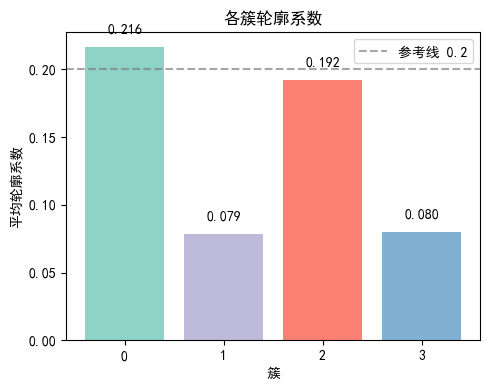

In [ ]:
#可视化：各簇平均轮廓柱状图
fig,ax=plt.subplots(figsize=(5,4))
colors = ["#8dd3c7", "#bebada", "#fb8072", "#80b1d3"] 
bars = ax.bar(range(n_clusters), means, color=colors)
ax.set_xlabel("簇")
ax.set_ylabel("平均轮廓系数")
ax.set_title("各簇轮廓系数")
ax.set_xticks(range(n_clusters))
ax.axhline(y=0.2, color="gray", linestyle="--", alpha=0.7, label="参考线 0.2")
ax.legend()
for i, v in enumerate(means):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

### 簇画像：特征、风险水平、授信策略

按簇统计特征均值、违约率、净收益，并打上业务标签（低风险优质 / 高负债高风险 / 高收入高额度 / 潜在违约），输出授信策略建议。

In [63]:
agg_dict={'cnt':('net_profit','count'),'avg_net_profit':('net_profit','mean'),'default_rate':('is_default','mean')}

for i in feat_cols:
    agg_dict[f'avg_{i}']=(i,'mean')

agg=cl_df.groupby('cluster').agg(**agg_dict)
agg

,cnt,avg_net_profit,default_rate,avg_annual_inc,avg_dti,avg_installment_inc_ratio,avg_delinq_2yrs,avg_num_tl_90g_dpd_24m,avg_pub_rec_bankruptcies,avg_inq_last_6mths,avg_revol_util,avg_loan_amnt,avg_int_rate,avg_term_months,avg_emp_length_num,avg_home_ownership_num
cluster,,,,,,,,,,,,,,,,
0,87334,-9287.311437,0.010122,74803.244009,18.239303,0.005768,0.189113,0.031294,0.000000,0.421875,42.730570,11125.935489,11.680697,36.141800,5.612030,0.943584
1,2222,-12471.927447,0.013501,96436.747772,17.050194,0.005627,4.310081,2.392439,0.045455,0.551755,46.226733,14722.704770,15.328411,42.642664,6.158866,1.217822
2,19211,-12582.323303,0.012909,77416.696066,19.022638,0.006512,0.113112,0.019416,1.013013,0.575556,40.537036,14832.979803,13.388410,43.875488,6.327208,1.142366
3,59214,-21286.110084,0.013730,100453.404750,21.310627,0.008397,0.172088,0.025433,0.000220,0.417047,48.688275,24526.389030,14.325107,54.955112,6.408518,1.314537


In [64]:
default_rate = agg["default_rate"]
dti_col = agg["avg_dti"]
annual_col = agg["avg_annual_inc"]
labels = ["低风险优质客户", "高负债高风险客户", "高收入高额度客户", "潜在违约客户"]
cluster_to_label = {}
remaining = list(agg.index)
# 1) 潜在违约：default_rate 最高
c_bad = default_rate.loc[remaining].idxmax()
cluster_to_label[c_bad] = "潜在违约客户"
remaining.remove(c_bad)

# 2) 高负债高风险：剩余中 DTI 最高
c_high_dti = dti_col.loc[remaining].idxmax()
cluster_to_label[c_high_dti] = "高负债高风险客户"
remaining.remove(c_high_dti)

# 3) 高收入高额度：剩余中 annual_inc 或 loan_amnt 最高
c_high_inc = annual_col.loc[remaining].idxmax()
cluster_to_label[c_high_inc] = "高收入高额度客户"
remaining.remove(c_high_inc)
# 4) 低风险优质：最后剩余
for i in remaining:
    cluster_to_label[i] = "低风险优质客户"
agg["客户类型"] = agg.index.map(cluster_to_label)

# 风险水平（按违约率简化为 低/中/高）
agg["风险水平"] = agg["default_rate"].apply(lambda r: "高" if r >= 0.02 else ("中" if r >= 0.01 else "低"))

In [65]:
# 授信策略建议
def strategy(row):
    t = row["客户类型"]
    if "低风险优质" in t:
        return "可放宽额度与期限，优先投放，适度优惠利率"
    if "高负债高风险" in t:
        return "收紧额度或缩短期限，提高利率覆盖风险，加强贷后监控"
    if "高收入高额度" in t:
        return "可给较高额度与较长期限，利率适中，关注集中度"
    if "潜在违约" in t:
        return "从严准入，降低额度上限，高定价或拒绝，加强催收与核销准备"
    return "标准审批与定价"
agg["授信策略"] = agg.apply(strategy, axis=1)

# 最终输出：每类客户特征 + 风险水平 + 授信策略
out_cols = ["客户类型", "cnt", "default_rate", "风险水平", "avg_net_profit"]

out_cols.insert(3, "avg_dti")

out_cols.insert(3, "avg_int_rate")
out_cols += ["授信策略"]
result = agg[[c for c in out_cols if c in agg.columns]].copy()
result = result.rename(columns={"cnt": "笔数", "default_rate": "违约率", "avg_net_profit": "平均净收益", "avg_dti": "平均DTI", "avg_int_rate": "平均利率"})
display(result)
print("\n各簇特征摘要（部分）：")
display(agg[[c for c in agg.columns if c.startswith("avg_") and c not in ["avg_net_profit"]]].round(2).head())

,客户类型,笔数,违约率,平均利率,平均DTI,风险水平,平均净收益,授信策略
cluster,,,,,,,,
0,低风险优质客户,87334,0.010122,11.680697,18.239303,中,-9287.311437,可放宽额度与期限，优先投放，适度优惠利率
1,高收入高额度客户,2222,0.013501,15.328411,17.050194,中,-12471.927447,可给较高额度与较长期限，利率适中，关注集中度
2,高负债高风险客户,19211,0.012909,13.388410,19.022638,中,-12582.323303,收紧额度或缩短期限，提高利率覆盖风险，加强贷后监控
3,潜在违约客户,59214,0.013730,14.325107,21.310627,中,-21286.110084,从严准入，降低额度上限，高定价或拒绝，加强催收与核销准备



各簇特征摘要（部分）：


,avg_annual_inc,avg_dti,avg_installment_inc_ratio,avg_delinq_2yrs,avg_num_tl_90g_dpd_24m,avg_pub_rec_bankruptcies,avg_inq_last_6mths,avg_revol_util,avg_loan_amnt,avg_int_rate,avg_term_months,avg_emp_length_num,avg_home_ownership_num
cluster,,,,,,,,,,,,,
0,74803.24,18.24,0.01,0.19,0.03,0.00,0.42,42.73,11125.94,11.68,36.14,5.61,0.94
1,96436.75,17.05,0.01,4.31,2.39,0.05,0.55,46.23,14722.70,15.33,42.64,6.16,1.22
2,77416.70,19.02,0.01,0.11,0.02,1.01,0.58,40.54,14832.98,13.39,43.88,6.33,1.14
3,100453.40,21.31,0.01,0.17,0.03,0.00,0.42,48.69,24526.39,14.33,54.96,6.41,1.31


- **低风险优质客户**（约 8.7 万笔）：违约率最低（约 1.01%），平均利率约 11.7%，平均净收益 -0.93 万；建议放宽额度与期限、优先投放、适度优惠利率。  
- **高收入高额度客户**（约 0.2 万笔）：笔均金额与利率较高，违约率约 1.35%；建议给较高额度和期限、利率适中、关注集中度。  
- **高负债高风险客户**（约 1.9 万笔）：DTI 与破产记录等偏高；建议收紧额度/期限、提高定价、加强贷后监控。  
- **潜在违约客户**（约 5.9 万笔）：违约率最高（约 1.37%）、平均净收益亏损最大（约 2.1 万）；建议从严准入、降额度或高定价。  


### 特征相关性 

- 相关性矩阵与热力图展示 13 个聚类特征之间的线性相关程度，用于检查多重共线性与特征冗余。  
- 若某两个特征高度相关，可考虑只保留其一或做业务取舍，避免聚类被重复信息主导；特征选择时已考虑业务含义与稳定性，相关性用于验证


                       annual_inc       dti  installment_inc_ratio  \
annual_inc               1.000000 -0.119477              -0.140516   
dti                     -0.119477  1.000000               0.568702   
installment_inc_ratio   -0.140516  0.568702               1.000000   
delinq_2yrs              0.040078 -0.024826              -0.032660   
num_tl_90g_dpd_24m       0.007841 -0.020799              -0.015572   
pub_rec_bankruptcies    -0.021540 -0.008598              -0.010552   
inq_last_6mths           0.034109  0.005492              -0.040335   
revol_util               0.056768  0.130730               0.027163   
loan_amnt                0.225739  0.066399               0.303113   
int_rate                -0.054736  0.136995               0.090370   
term_months              0.037010  0.059710               0.049427   
emp_length_num           0.060023  0.035832              -0.037392   
home_ownership_num       0.126528  0.061149              -0.035744   

                   

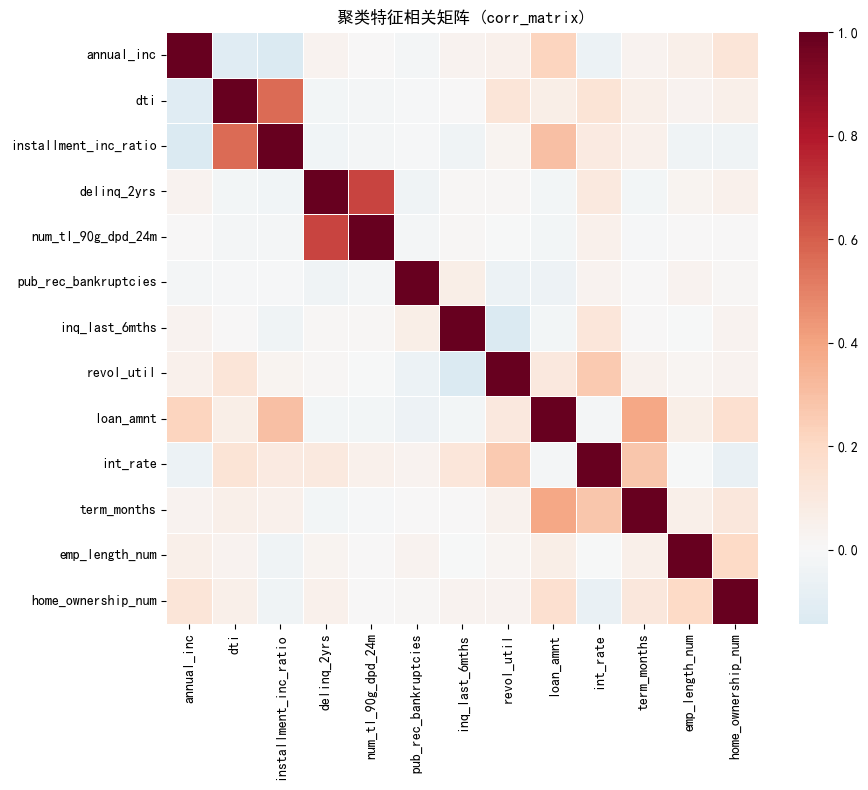

In [77]:
import seaborn as sns

# 1) 相关矩阵：聚类特征之间的相关性
corr = cl_df[feat_cols].corr()
print(corr)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="RdBu_r", center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("聚类特征相关矩阵 (corr_matrix)")
plt.tight_layout()
plt.show()


### 可视化：按簇看利率与净收益
- 散点图按簇着色：横轴利率、纵轴净收益，可直观看到不同簇在「定价–收益」平面上的分布。  
- 高利率不一定对应高净收益（违约导致亏损），潜在违约客户簇往往在高利率、低/负净收益区域；低风险优质客户多集中在利率较低、亏损相对较小的区域。  
- 支撑「按风险定价、对高风险客群提价或收紧」的结论。

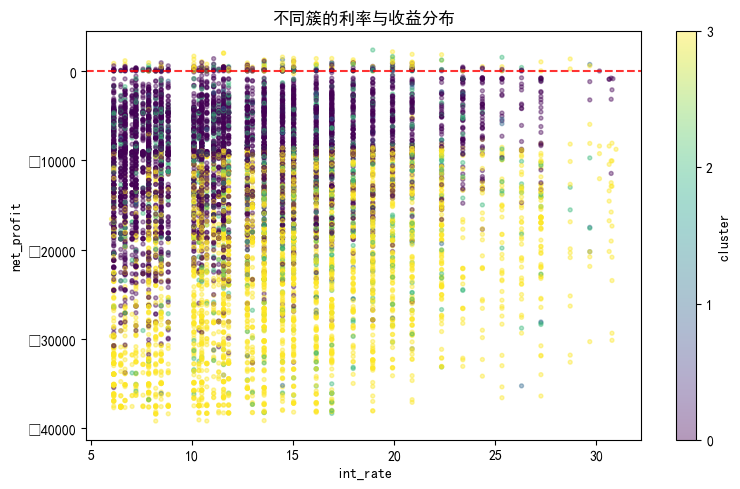

In [80]:
# 这里数据量较大，用抽样绘图
n_plot = 10000
idx = np.random.RandomState(42).choice(len(cl_df), n_plot, replace=False)
plot_df = cl_df.iloc[idx]
int_rate_num = plot_df["int_rate_num"] if "int_rate_num" in plot_df.columns else pd.to_numeric(plot_df["int_rate"].astype(str).str.replace("%", "", regex=False), errors="coerce")

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(int_rate_num, plot_df["net_profit"], c=plot_df["cluster"], cmap="viridis", alpha=0.4, s=8)
ax.axhline(0, color="red", linestyle="--", alpha=0.8)
ax.set_xlabel("int_rate")
ax.set_ylabel("net_profit")
ax.set_title("不同簇的利率与收益分布")
plt.colorbar(sc, label="cluster",ticks=[0, 1, 2, 3])
plt.tight_layout()
plt.show()

In [47]:
#三类客户：k=3
n_clusters_3=3
cl_df_3=df.copy()
km=KMeans(n_clusters=n_clusters_3,random_state=42,n_init=10) #用不同的初始中心跑10次
cl_df_3['cluster']=km.fit_predict(X_s)
print(cl_df_3["cluster"])
cl_df_3["cluster"].value_counts()


0         0
1         1
2         2
3         2
4         1
         ..
167976    0
167977    0
167978    0
167979    2
167980    2
Name: cluster, Length: 167981, dtype: int32


cluster
2    58432
0    55784
1    53765
Name: count, dtype: int64

In [ ]:
#总体轮廓系数
score_3=silhouette_score(X_s,cl_df_3["cluster"])


总体轮廓系数:0.1636


In [52]:
print(f'总体轮廓系数:{score_3:.4f}')

总体轮廓系数:0.1182


In [53]:
#每簇平均轮廓
sil_per_3=silhouette_samples(X_s,cl_df_3["cluster"])
means_3=[]
for i in range(n_clusters_3):
    mean_sil_3=sil_per_3[cl_df_3["cluster"]==i].mean()
    means_3.append(mean_sil_3)
    print(f'簇{i}的平均轮廓是：{mean_sil_3:.4f}')

簇0的平均轮廓是：0.1928
簇1的平均轮廓是：0.1052
簇2的平均轮廓是：0.0591


In [51]:
#五类客户：k=5
n_clusters_5=5
cl_df_5=df.copy()
km_5=KMeans(n_clusters=n_clusters_5,random_state=42,n_init=10) #用不同的初始中心跑10次
cl_df_5['cluster']=km_5.fit_predict(X_s)
print(cl_df_5["cluster"])
cl_df_5["cluster"].value_counts()

#总体轮廓系数
score_5=silhouette_score(X_s,cl_df_5["cluster"])
print(f'总体轮廓系数:{score_5:.4f}')
#每簇平均轮廓
sil_per_5=silhouette_samples(X_s,cl_df_5["cluster"])
means_5=[]
for i in range(n_clusters_5):
    mean_sil_5=sil_per_5[cl_df_5["cluster"]==i].mean()
    means_5.append(mean_sil_5)
    print(f'簇{i}的平均轮廓是：{mean_sil_5:.4f}')

0         4
1         4
2         1
3         1
4         2
         ..
167976    3
167977    3
167978    3
167979    1
167980    1
Name: cluster, Length: 167981, dtype: int32
总体轮廓系数:0.1371
簇0的平均轮廓是：0.0688
簇1的平均轮廓是：0.1020
簇2的平均轮廓是：0.1083
簇3的平均轮廓是：0.1905
簇4的平均轮廓是：0.1695
